In [1]:
# src/sh_ssw_methods/u_wind_decel.py
from __future__ import annotations
import numpy as np
import pandas as pd
import xarray as xr

In [2]:
from utils.event_iden_funcs import (
    build_events_df,
)

In [9]:
def detect_u_decel_events(
    u: xr.DataArray,
    *,
    # Algorithm controls
    wdw: int = 10,                 # event window length (days)
    drop_per_day: float | None = None,
    mode: str = "decel",           # "decel" or "accel"
    min_gap_days: int = 20,        # next event must be at least this far after the previous
    ratio_thres: float = 1.2,      # max(|window range| / |window end-start|)
    time_dim: str = "time",
    # Metadata (for build_events_df)
    method: str = "u_wind_decel",
    data_source: str | None = None,
    level_hpa: float | None = None,
    latitude: float | None = None,
    lat_band: str | None = None,
) -> tuple[pd.DataFrame, pd.DatetimeIndex, np.ndarray]:
    """
    Identify deceleration/acceleration events in a zonal-mean wind time series.

    Reimplements the logic from Wu et al. (2022)-style detection:
      - event magnitude = u[t+wdw-1] - u[t] (over a wdw-day window)
      - for decel, require diff <= drop_per_day * wdw
        for accel, require diff >= drop_per_day * wdw
      - ratio = (max(window)-min(window)) / |diff|  <= ratio_thres
      - enforce separation by min_gap_days AND, within that gap window,
        keep only the stronger event (more negative for decel, more positive for accel)

    Returns
    -------
    events_df : pd.DataFrame
        tidy table via build_events_df (with only `date` = onset)
    event_dates : pd.DatetimeIndex
        onset dates
    drop_vals : np.ndarray
        event magnitudes (end - start over the window)
    """

    # make sure input is xr.DataArray
    if not isinstance(u, xr.DataArray):
        raise TypeError(
            "detect_u_decel_events expects an xarray.DataArray. "
            "If you have a Dataset, select a variable first, e.g. ds['u']."
        )
    
    if time_dim not in u.dims:
        raise ValueError(f"Expected `{time_dim}` dimension in input DataArray.")
    if mode not in {"decel", "accel"}:
        raise ValueError("mode must be 'decel' or 'accel'.")

    # Choose a sensible default threshold if not provided (matches your original)
    if drop_per_day is None:
        # If level metadata is present, use it; else default to -2 m/s/day (10 hPa-like)
        if level_hpa in (10, 10.0):
            drop_per_day = -2.0 if mode == "decel" else 2.0
        elif level_hpa in (50, 50.0):
            drop_per_day = -1.0 if mode == "decel" else 1.0
        else:
            drop_per_day = -2.0 if mode == "decel" else 2.0

    # 1) Prepare a clean 1-D time series
    t = pd.to_datetime(u[time_dim].to_index())
    s = pd.Series(u.values, index=t)

    # 2) Compute window start→end diff and window range (vectorized)
    # Align "diff" with window START index
    s_end = s.shift(-(wdw - 1))         # value at t+wdw-1
    diff = s_end - s                    # window difference

    # Rolling range over forward-looking window:
    # We can compute a centered rolling on a reversed series to align at window start,
    # or use expanding on slices. Simpler: compute rolling max/min on forward windows via numpy stride.
    # For clarity (and still efficient), do this with pandas rolling on the *reversed* series, then flip back.
    sr = s[::-1]
    rmax = sr.rolling(window=wdw, min_periods=wdw).max()[::-1]
    rmin = sr.rolling(window=wdw, min_periods=wdw).min()[::-1]
    window_range = rmax - rmin

    # Keep only indices where a full window exists
    valid = ~diff.isna()
    diff = diff[valid]
    window_range = window_range[valid]

    # 3) Apply threshold and ratio filters
    drop_thres_total = drop_per_day * wdw
    if mode == "decel":
        cand_mask = (diff <= drop_thres_total)
        stronger_is = np.argmin   # more negative is stronger
        better = lambda a, b: a < b
    else:
        cand_mask = (diff >= drop_thres_total)
        stronger_is = np.argmax   # more positive is stronger
        better = lambda a, b: a > b

    ratio = (window_range / diff.abs()).replace([np.inf, -np.inf], np.nan)
    ratio_mask = ratio <= ratio_thres
    cand_idx = diff.index[cand_mask & ratio_mask & diff.notna() & ratio.notna()]

    if len(cand_idx) == 0:
        events_df = build_events_df(
            dates=[],
            method=method,
            definition=definition or f"{mode}_wdw{wdw}_ratio{ratio_thres:g}_thr{drop_per_day:g}perday",
            data_source=data_source or "",
            threshold=drop_per_day,
            level_hpa=level_hpa,
            latitude=latitude,
            lat_band=lat_band,
            notes=notes or f"min_gap={min_gap_days}d",
        )
        return events_df, pd.DatetimeIndex([]), np.array([])

    # 4) Enforce min-gap and “stronger-in-window” replacement
    cand = pd.DataFrame({
        "onset": cand_idx,
        "diff": diff.loc[cand_idx].values,            # event magnitude over window
    }).sort_values("onset")

    selected_onsets: list[pd.Timestamp] = []
    selected_diffs: list[float] = []

    # We walk candidates in time; if a candidate is within min_gap_days of the last kept event,
    # we keep only the stronger one (compare magnitudes according to mode).
    for onset, dval in zip(cand["onset"].values, cand["diff"].values):
        if not selected_onsets:
            selected_onsets.append(onset)
            selected_diffs.append(dval)
            continue

        gap_days = int((pd.Timestamp(onset) - pd.Timestamp(selected_onsets[-1])) / pd.Timedelta(days=1))

        if gap_days >= min_gap_days:
            # far enough — accept as new event
            selected_onsets.append(onset)
            selected_diffs.append(dval)
        else:
            # within gap — replace if stronger
            if better(dval, selected_diffs[-1]):
                selected_onsets[-1] = onset
                selected_diffs[-1] = dval
            # else keep existing

    event_dates = pd.DatetimeIndex(selected_onsets)
    drop_vals = np.asarray(selected_diffs)

    # 5) Build unified table
    events_df = build_events_df(
        dates=event_dates,
        method=method,
        definition= f"{mode}_wdw{wdw}_ratio{ratio_thres:g}_thr{drop_per_day:g}perday",
        data_source=data_source or "",
        threshold=f"{drop_per_day}ms-1/day",
        level_hpa=level_hpa,
        latitude=latitude,
        lat_band=lat_band,
        notes=f"min_gap={min_gap_days}d; window={wdw}d",
        extra_cols={"drop_val": drop_vals}, 
    )

    return events_df, event_dates


- test function

In [4]:
import os

In [5]:
os.path.abspath(os.path.join(os.getcwd(), "..", ".."))

'/net/cfc/s2s/rachwu/scripts/sh_ssw_impact/aparc_project/SouthernWarmings_module'

In [6]:
# open sample total column ozone data
u1060_path =  os.path.abspath(os.path.join(os.getcwd(), "..", ".."))+ "/data/" +"u1060s_era5_1959_2023.nc"
xu1060 = xr.open_dataset(u1060_path)

In [18]:
da = xu1060['u1060S'].sel(time=slice("1980","2020"))

In [22]:
da

<xarray.DataArray 'u1060S' (time: 59904)> Size: 240kB
array([-11.8342  , -12.366327, -11.994308, ..., -14.270244, -14.379604,
       -14.469212], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 479kB 1980-01-01 ... 2020-12-31T18:00:00
    lat      float64 8B ...
    plev     float64 8B ...

In [19]:
events_df, event_dates = detect_u_decel_events(da)

In [20]:
event_dates

DatetimeIndex(['1984-10-03 18:00:00', '1990-10-04 00:00:00',
               '1991-09-21 12:00:00', '1992-09-02 18:00:00',
               '1997-11-02 00:00:00', '2000-09-22 12:00:00',
               '2002-08-21 00:00:00', '2002-09-20 18:00:00',
               '2003-10-02 12:00:00', '2005-09-19 06:00:00',
               '2007-09-17 18:00:00', '2008-10-11 00:00:00',
               '2016-09-07 00:00:00', '2019-09-04 12:00:00'],
              dtype='datetime64[ns]', freq=None)

In [21]:
events_df

,date,method,definition,data_source,threshold,level_hpa,latitude,lat_band,notes,drop_val
0,1984-10-03 18:00:00,u_wind_decel,decel_wdw10_ratio1.2_thr-2perday,,-2.0ms-1/day,None,None,<NA>,min_gap=20d; window=10d,-29.089287
1,1990-10-04 00:00:00,u_wind_decel,decel_wdw10_ratio1.2_thr-2perday,,-2.0ms-1/day,None,None,<NA>,min_gap=20d; window=10d,-22.772488
2,1991-09-21 12:00:00,u_wind_decel,decel_wdw10_ratio1.2_thr-2perday,,-2.0ms-1/day,None,None,<NA>,min_gap=20d; window=10d,-22.080673
3,1992-09-02 18:00:00,u_wind_decel,decel_wdw10_ratio1.2_thr-2perday,,-2.0ms-1/day,None,None,<NA>,min_gap=20d; window=10d,-21.866943
4,1997-11-02 00:00:00,u_wind_decel,decel_wdw10_ratio1.2_thr-2perday,,-2.0ms-1/day,None,None,<NA>,min_gap=20d; window=10d,-22.467836
5,2000-09-22 12:00:00,u_wind_decel,decel_wdw10_ratio1.2_thr-2perday,,-2.0ms-1/day,None,None,<NA>,min_gap=20d; window=10d,-26.756741
6,2002-08-21 00:00:00,u_wind_decel,decel_wdw10_ratio1.2_thr-2perday,,-2.0ms-1/day,None,None,<NA>,min_gap=20d; window=10d,-29.735279
7,2002-09-20 18:00:00,u_wind_decel,decel_wdw10_ratio1.2_thr-2perday,,-2.0ms-1/day,None,None,<NA>,min_gap=20d; window=10d,-30.976959
8,2003-10-02 12:00:00,u_wind_decel,decel_wdw10_ratio1.2_thr-2perday,,-2.0ms-1/day,None,None,<NA>,min_gap=20d; window=10d,-24.091248
9,2005-09-19 06:00:00,u_wind_decel,decel_wdw10_ratio1.2_thr-2perday,,-2.0ms-1/day,None,None,<NA>,min_gap=20d; window=10d,-32.078751


- re-develop

In [42]:
def detect_u_decel_events(
    u: xr.DataArray,
    *,
    # Window definition (in DAYS; code infers samples from the time step)
    wdw: int = 10,
    # Choose ONE of the two thresholding modes:
    drop_per_day: float | None = None,   # fixed threshold (m/s per day)
    percentile: float | None = None,     # e.g., 60 -> keep strongest 40% (by magnitude)
    # Algorithm controls
    mode: str = "decel",                 # "decel" or "accel"
    min_gap_days: int = 20,
    ratio_thres: float = 1.2,            # (max-min)/|diff| must be <= ratio_thres
    time_dim: str = "time",
    # Metadata
    method: str = "u_wind_decel",
    definition: str | None = None,
    data_source: str | None = None,
    level_hpa: float | None = None,
    latitude: float | None = None,
    lat_band: str | None = None,
    notes: str | None = None,
) -> tuple[pd.DataFrame, pd.DatetimeIndex, np.ndarray]:
    """
    Detect acceleration/deceleration events with either a fixed per-day threshold
    or a data-driven percentile threshold on event magnitudes.

    Window diff: diff(t) = u[t+window_end] - u[t] over a forward window of length `wdw` days.
    For decel, negative diffs are candidates; for accel, positive diffs.
    """
    # --- validation
    if not isinstance(u, xr.DataArray):
        raise TypeError("detect_u_decel_events expects an xarray.DataArray.")
    if time_dim not in u.dims:
        raise ValueError(f"Expected `{time_dim}` in input DataArray.")
    if mode not in {"decel", "accel"}:
        raise ValueError("mode must be 'decel' or 'accel'.")
    if (drop_per_day is None) and (percentile is None):
        # sensible defaults if nothing specified
        if level_hpa in (10, 10.0):
            drop_per_day = -2.0 if mode == "decel" else 2.0
        elif level_hpa in (50, 50.0):
            drop_per_day = -1.0 if mode == "decel" else 1.0
        else:
            drop_per_day = -2.0 if mode == "decel" else 2.0

    # --- 1) 1-D series + infer sampling; map wdw days -> n samples
    t = pd.to_datetime(u[time_dim].to_index())
    s = pd.Series(u.values, index=t)

    if len(s) < 2:
        # too short for any window
        empty = build_events_df(
            dates=[],
            method=method,
            definition=definition or f"{mode}_wdw{wdw}",
            data_source=data_source or "",
            level_hpa=level_hpa, latitude=latitude, lat_band=lat_band, notes=notes,
        )
        return empty, pd.DatetimeIndex([]), np.array([])

    dt = pd.Series(t).diff().dropna().median()
    dt_days = float(dt / pd.Timedelta(days=1))
    n = max(1, int(round(wdw / dt_days)))        # samples in window
    window_days = n * dt_days                     # actual days spanned by window

    # --- 2) forward-window diff and range aligned to window START
    s_end = s.shift(-(n - 1))                    # value at t + (n-1 steps)
    diff = s_end - s

    sr = s[::-1]
    rmax = sr.rolling(window=n, min_periods=n).max()[::-1]
    rmin = sr.rolling(window=n, min_periods=n).min()[::-1]
    window_range = (rmax - rmin)

    valid = ~diff.isna()
    diff = diff[valid]
    window_range = window_range[valid]

    # --- 3) candidates by sign + coherence ratio (no magnitude threshold yet)
    if mode == "decel":
        sign_mask = (diff <= 0)
        better = lambda a, b: a < b  # more negative is stronger
    else:
        sign_mask = (diff >= 0)
        better = lambda a, b: a > b  # more positive is stronger

    ratio = (window_range / diff.abs()).replace([np.inf, -np.inf], np.nan)
    ratio_mask = ratio <= ratio_thres
    cand_idx = diff.index[sign_mask & ratio_mask & diff.notna() & ratio.notna()]

    if len(cand_idx) == 0:
        empty = build_events_df(
            dates=[],
            method=method,
            definition=definition or f"{mode}_wdw{wdw}_ratio{ratio_thres:g}",
            data_source=data_source or "",
            level_hpa=level_hpa, latitude=latitude, lat_band=lat_band,
            notes=(notes or "") + f"; window={wdw}d",
        )
        return empty, pd.DatetimeIndex([]), np.array([])

    # --- 4) min-gap with "keep stronger within the gap" selection
    cand = pd.DataFrame({"onset": cand_idx, "diff": diff.loc[cand_idx].values}) \
            .sort_values("onset")

    selected_onsets: list[pd.Timestamp] = []
    selected_diffs: list[float] = []

    for onset, dval in zip(cand["onset"].values, cand["diff"].values):
        if not selected_onsets:
            selected_onsets.append(onset); selected_diffs.append(dval); continue
        gap_days = int((pd.Timestamp(onset) - pd.Timestamp(selected_onsets[-1])) / pd.Timedelta(days=1))
        if gap_days >= min_gap_days:
            selected_onsets.append(onset); selected_diffs.append(dval)
        else:
            if better(dval, selected_diffs[-1]):
                selected_onsets[-1] = onset
                selected_diffs[-1] = dval

    event_dates = pd.DatetimeIndex(selected_onsets)
    drop_vals = np.asarray(selected_diffs)  # signed: negative (decel) / positive (accel)

    # --- 5) Percentile mode: compute magnitude cutoff and filter
    used_threshold_per_day: float | None = None
    used_threshold_total: float | None = None
    used_mode = "fixed"
    if percentile is not None:
        if len(drop_vals) == 0:
            # nothing to percentile over
            pass
        else:
            mag = np.abs(drop_vals)                 # magnitude in m/s over the window
            cutoff_mag = np.percentile(mag, percentile)
            keep = mag >= cutoff_mag                # keep strongest (100 - p)% events
            event_dates = event_dates[keep]
            drop_vals = drop_vals[keep]

            used_threshold_total = float(cutoff_mag)                 # m/s over window
            # convert to per-day, set signed according to mode
            signed = -1.0 if mode == "decel" else 1.0
            used_threshold_per_day = signed * (cutoff_mag / window_days)
            used_mode = f"percentile_{percentile:g}"

    # --- 6) Fixed-threshold mode (if requested in addition or instead)
    # If percentile is None, apply fixed threshold here:
    if percentile is None and drop_per_day is not None:
        total = drop_per_day * window_days          # signed total over window
        if mode == "decel":
            keep = drop_vals <= total               # total is negative
        else:
            keep = drop_vals >= total
        event_dates = event_dates[keep]
        drop_vals = drop_vals[keep]
        used_threshold_per_day = float(drop_per_day)
        used_threshold_total = float(abs(total))    # report magnitude for clarity
        used_mode = "fixed"

    # --- 7) Build unified table
    definition_auto = (
        f"{mode}_{used_mode}_wdw{wdw}_ratio{ratio_thres:g}"
        + ("" if used_threshold_per_day is None else f"_thr{used_threshold_per_day:.3g}/day")
    )

    events_df = build_events_df(
        dates=event_dates,
        method=method,
        definition=definition or definition_auto,
        data_source=data_source or "",
        threshold=used_threshold_per_day,          # per-day signed threshold used
        level_hpa=level_hpa,
        latitude=latitude,
        lat_band=lat_band,
        notes=((notes or "") + f"; min_gap={min_gap_days}d; window≈{window_days:.2f}d"),
        extra_cols={
            "drop_val": drop_vals,                 # signed total change over the window (m/s)
            "window_days": np.repeat(window_days, len(event_dates)),
            # "threshold_total_mag": (
            #     [] if used_threshold_total is None else np.repeat(used_threshold_total, len(event_dates))
            #),
        },
    )

    return events_df, event_dates#, drop_vals


In [104]:
time_dim = "time"
percentile = 60

In [105]:
da = xu1060['u1060S'].sel(time=slice("1980","2020"))
da = da.resample({time_dim: "1D"}).mean()

In [106]:
events_df, event_dates = detect_u_decel_events(da, percentile=percentile)

In [107]:
events_df

,date,method,definition,data_source,threshold,level_hpa,latitude,lat_band,notes,drop_val,window_days
0,1980-09-29,u_wind_decel,decel_percentile_60_wdw10_ratio1.2_thr-1.73/day,,-1.734516,None,None,<NA>,; min_gap=20d; window≈10.00d,-27.518852,10.0
1,1980-10-31,u_wind_decel,decel_percentile_60_wdw10_ratio1.2_thr-1.73/day,,-1.734516,None,None,<NA>,; min_gap=20d; window≈10.00d,-23.568851,10.0
2,1981-09-16,u_wind_decel,decel_percentile_60_wdw10_ratio1.2_thr-1.73/day,,-1.734516,None,None,<NA>,; min_gap=20d; window≈10.00d,-22.723045,10.0
3,1981-11-11,u_wind_decel,decel_percentile_60_wdw10_ratio1.2_thr-1.73/day,,-1.734516,None,None,<NA>,; min_gap=20d; window≈10.00d,-25.360950,10.0
4,1982-10-01,u_wind_decel,decel_percentile_60_wdw10_ratio1.2_thr-1.73/day,,-1.734516,None,None,<NA>,; min_gap=20d; window≈10.00d,-30.042351,10.0
...,...,...,...,...,...,...,...,...,...,...,...
92,2019-08-25,u_wind_decel,decel_percentile_60_wdw10_ratio1.2_thr-1.73/day,,-1.734516,None,None,<NA>,; min_gap=20d; window≈10.00d,-31.781330,10.0
93,2020-09-09,u_wind_decel,decel_percentile_60_wdw10_ratio1.2_thr-1.73/day,,-1.734516,None,None,<NA>,; min_gap=20d; window≈10.00d,-19.526237,10.0
94,2020-10-07,u_wind_decel,decel_percentile_60_wdw10_ratio1.2_thr-1.73/day,,-1.734516,None,None,<NA>,; min_gap=20d; window≈10.00d,-22.385166,10.0
95,2020-10-28,u_wind_decel,decel_percentile_60_wdw10_ratio1.2_thr-1.73/day,,-1.734516,None,None,<NA>,; min_gap=20d; window≈10.00d,-21.340199,10.0


(array([ 1.,  0.,  0.,  0.,  4.,  9., 35., 55., 48., 89.]),
 array([-77.19924927, -69.54788208, -61.89651489, -54.24514771,
        -46.59378052, -38.94241333, -31.29104805, -23.63968086,
        -15.98831367,  -8.33694649,  -0.6855793 ]),
 <BarContainer object of 10 artists>)

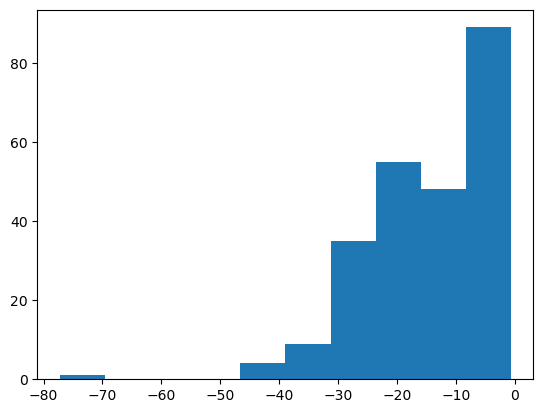

In [91]:
plt.hist(events_df['drop_val'])

In [76]:
test_perc = 90

In [77]:
np.percentile(np.abs(events_df['drop_val']), test_perc )

28.241378784179688

In [78]:
np.sum(events_df['drop_val'] < -np.percentile(np.abs(events_df['drop_val']), test_perc ))

24